# SDF workflow


In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sf_tools as sft


# set json file path
bracing_json_path = Path("./alice_result/251120/bracing/waveStackFields.json")  
profile_json_path = Path("./alice_result/251120/ext/waveStackFields.json")

print(f"Using bracing JSON file: {bracing_json_path.resolve()}")
print(f"Using profile JSON file: {profile_json_path.resolve()}")

with open(bracing_json_path, "r") as f:
    data_bracing = json.load(f)
with open(profile_json_path, "r") as f:
    data_profile = json.load(f)

Using bracing JSON file: C:\Users\Daxler.Zou\ZahaWork\Project\4359_exh_mocaup\251013_LatentSDF\Model\SDF_Stack\alice_result\251120\bracing\waveStackFields.json
Using profile JSON file: C:\Users\Daxler.Zou\ZahaWork\Project\4359_exh_mocaup\251013_LatentSDF\Model\SDF_Stack\alice_result\251120\ext\waveStackFields.json


## 1. SDF parse

structure of waveStackFeilds.json

In [2]:

# Inspect the top-level structure
print("data_bracing Top-level type:", type(data_bracing))
if isinstance(data_bracing, dict):
    print("Top-level keys:", list(data_bracing.keys()))
else:
    print("Non-dict JSON root (e.g. list)\n", data_bracing)

print("\n")
# inspect profiles
print("data_profile Top-level type:", type(data_profile))
if isinstance(data_profile, dict):
    print("Top-level keys:", list(data_profile.keys()))
else:
    print("Non-dict JSON root (e.g. list)\n", data_profile)

data_bracing Top-level type: <class 'dict'>
Top-level keys: ['bounds_max', 'bounds_min', 'iso_level', 'scalar_field_values_0', 'scalar_field_values_1', 'scalar_field_values_10', 'scalar_field_values_11', 'scalar_field_values_12', 'scalar_field_values_13', 'scalar_field_values_14', 'scalar_field_values_15', 'scalar_field_values_16', 'scalar_field_values_17', 'scalar_field_values_18', 'scalar_field_values_19', 'scalar_field_values_2', 'scalar_field_values_20', 'scalar_field_values_21', 'scalar_field_values_22', 'scalar_field_values_23', 'scalar_field_values_24', 'scalar_field_values_25', 'scalar_field_values_26', 'scalar_field_values_27', 'scalar_field_values_28', 'scalar_field_values_29', 'scalar_field_values_3', 'scalar_field_values_30', 'scalar_field_values_31', 'scalar_field_values_32', 'scalar_field_values_33', 'scalar_field_values_34', 'scalar_field_values_35', 'scalar_field_values_36', 'scalar_field_values_37', 'scalar_field_values_38', 'scalar_field_values_39', 'scalar_field_valu

### slice scalar_field to 2d array

In [3]:
# parse scalar field of bracing

print("\n---Parsing bracing scalar fields---\n")

iso_level_bracing, slice_count_bracing, bounds_max_bracing, bounds_min_bracing = sft.meta_data_info(data_bracing)
sft.stack_scalar_fields(data_bracing)
bracing_scalar_fields_2d, bracing_scalar_field_keys = sft.stack_scalar_fields(data_bracing)


# parse scalar field of profiles

print("\n---Parsing bracing scalar fields---\n")

iso_level_profile, slice_count_profile, bounds_max_profile, bounds_min_profile = sft.meta_data_info(data_profile)


sft.stack_scalar_fields(data_profile)
profile_scalar_fields_2d, profile_scalar_field_keys = sft.stack_scalar_fields(data_profile)

# match the shape of two fields
assert bracing_scalar_fields_2d.shape == profile_scalar_fields_2d.shape, "Scalar fields from bracing and profile do not match in shape!"
assert slice_count_bracing == slice_count_profile, "Slice counts do not match!"
assert bounds_max_bracing == bounds_max_profile, "Bounds max do not match!"
assert bounds_min_bracing == bounds_min_profile, "Bounds min do not match!"

# warn if iso-levels do not match
if iso_level_bracing != iso_level_profile:
    print("\nWARNING: Iso levels from bracing and profile do not match! use customized iso-level.")


---Parsing bracing scalar fields---

Bounds Max: [1.2395941019058228, 1.2395941019058228, 0.0]
Bounds Min: [-1.2395941019058228, -1.2395941019058228, 0.0]
Iso Level: 0.0
Slice Count: 60
Total Height: 200.0
Shape of 2D array: (60, 16384)
Number of scalar fields: 60
Values per field: 16384
Shape of 2D array: (60, 16384)
Number of scalar fields: 60
Values per field: 16384

---Parsing bracing scalar fields---

Bounds Max: [1.2395941019058228, 1.2395941019058228, 0.0]
Bounds Min: [-1.2395941019058228, -1.2395941019058228, 0.0]
Iso Level: 0.0
Slice Count: 60
Total Height: 200.0
Shape of 2D array: (60, 16384)
Number of scalar fields: 60
Values per field: 16384
Shape of 2D array: (60, 16384)
Number of scalar fields: 60
Values per field: 16384


## 2.Visulaize

global field check

[Bracing] Using grid size: nx=128, ny=128
[Bracing] Shape: (60, 16384)


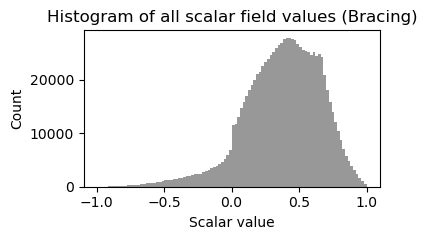

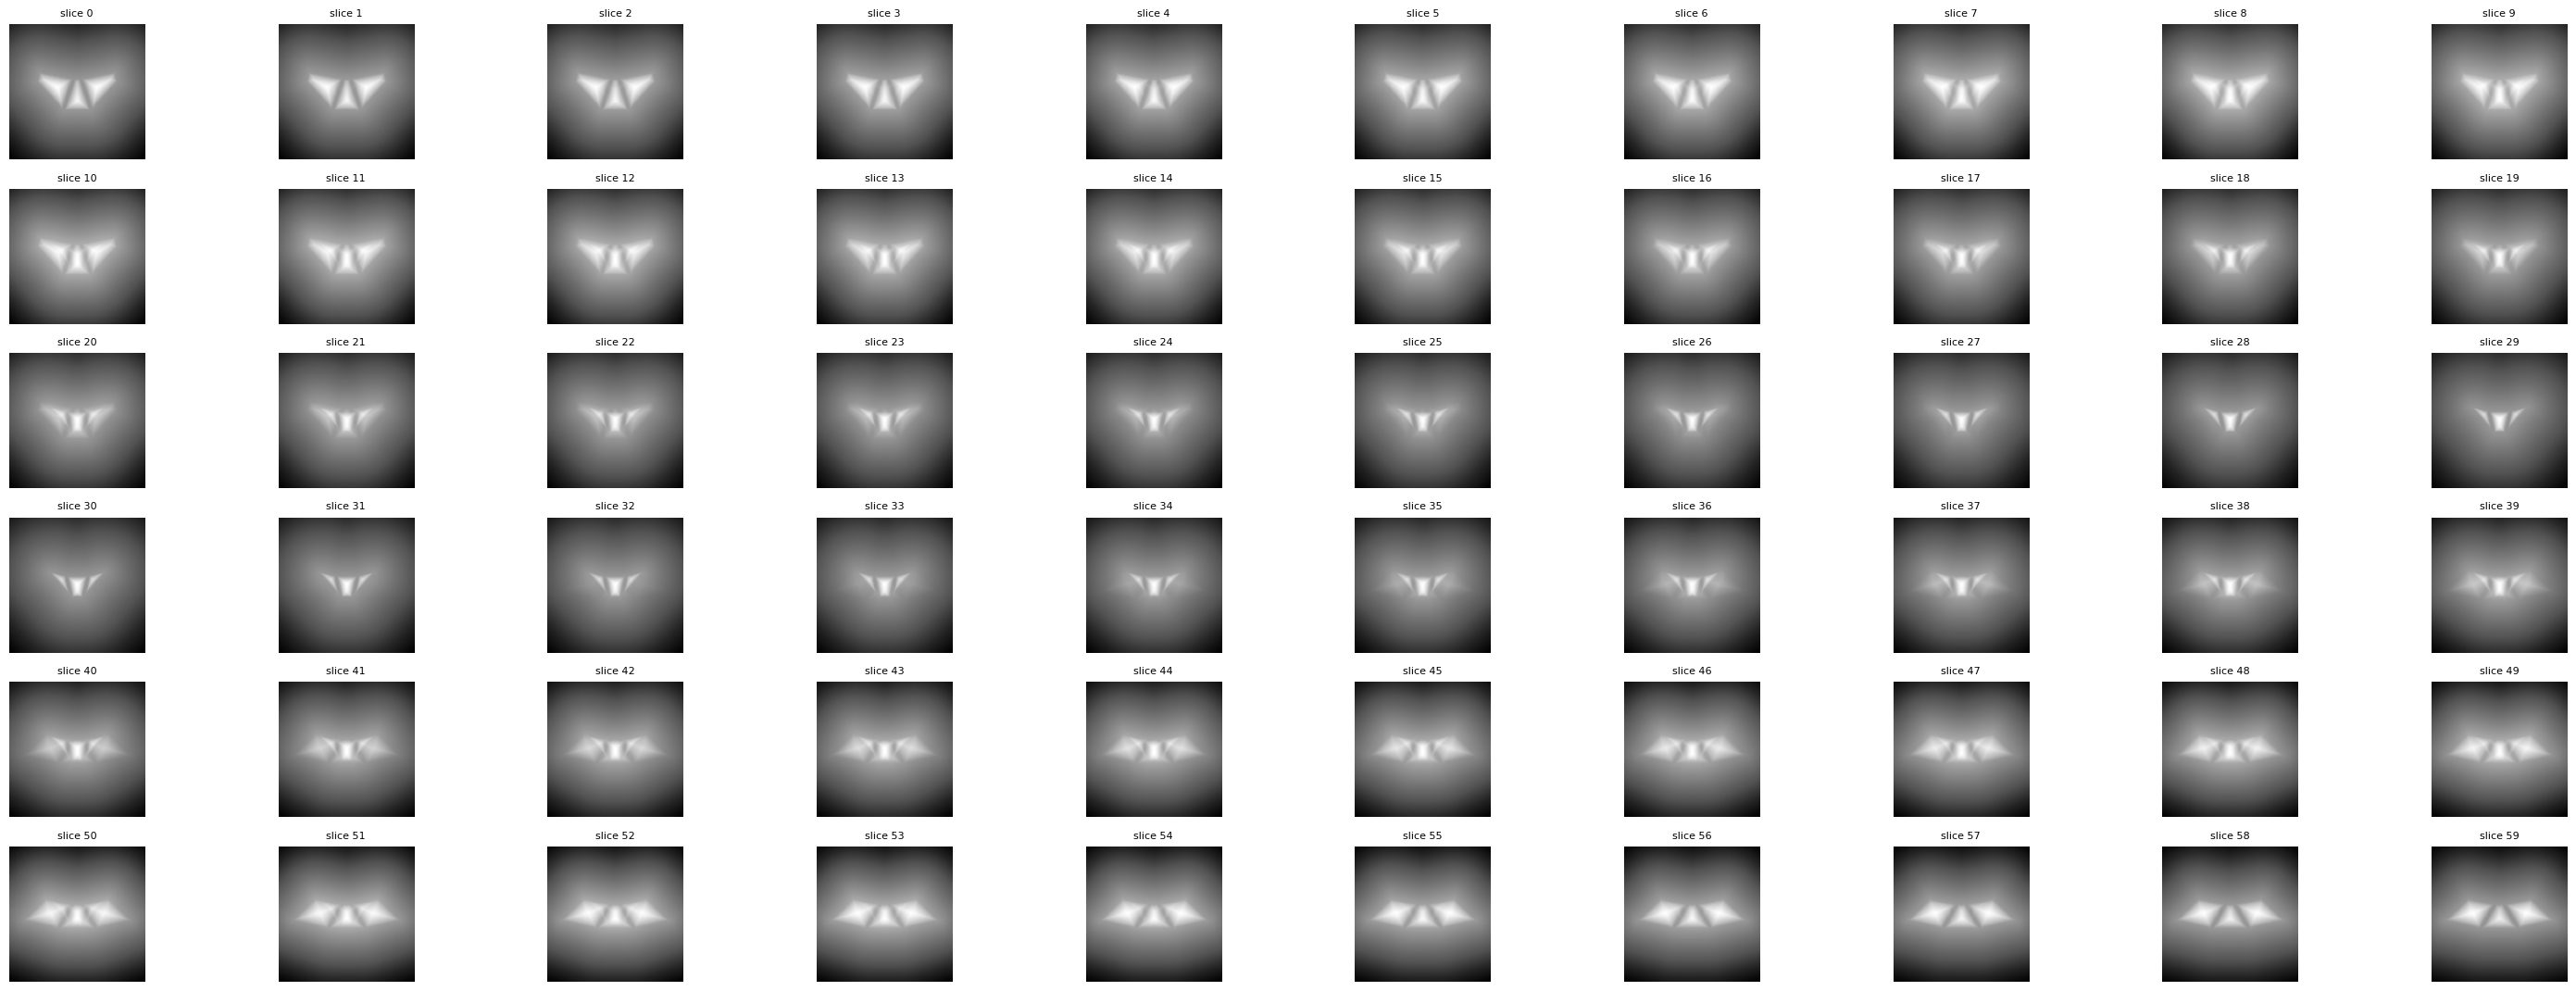

[Profile] Using grid size: nx=128, ny=128
[Profile] Shape: (60, 16384)


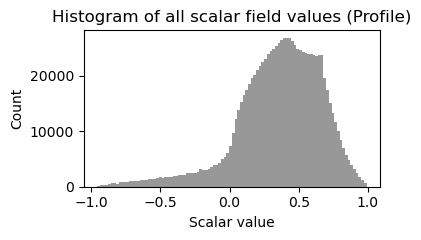

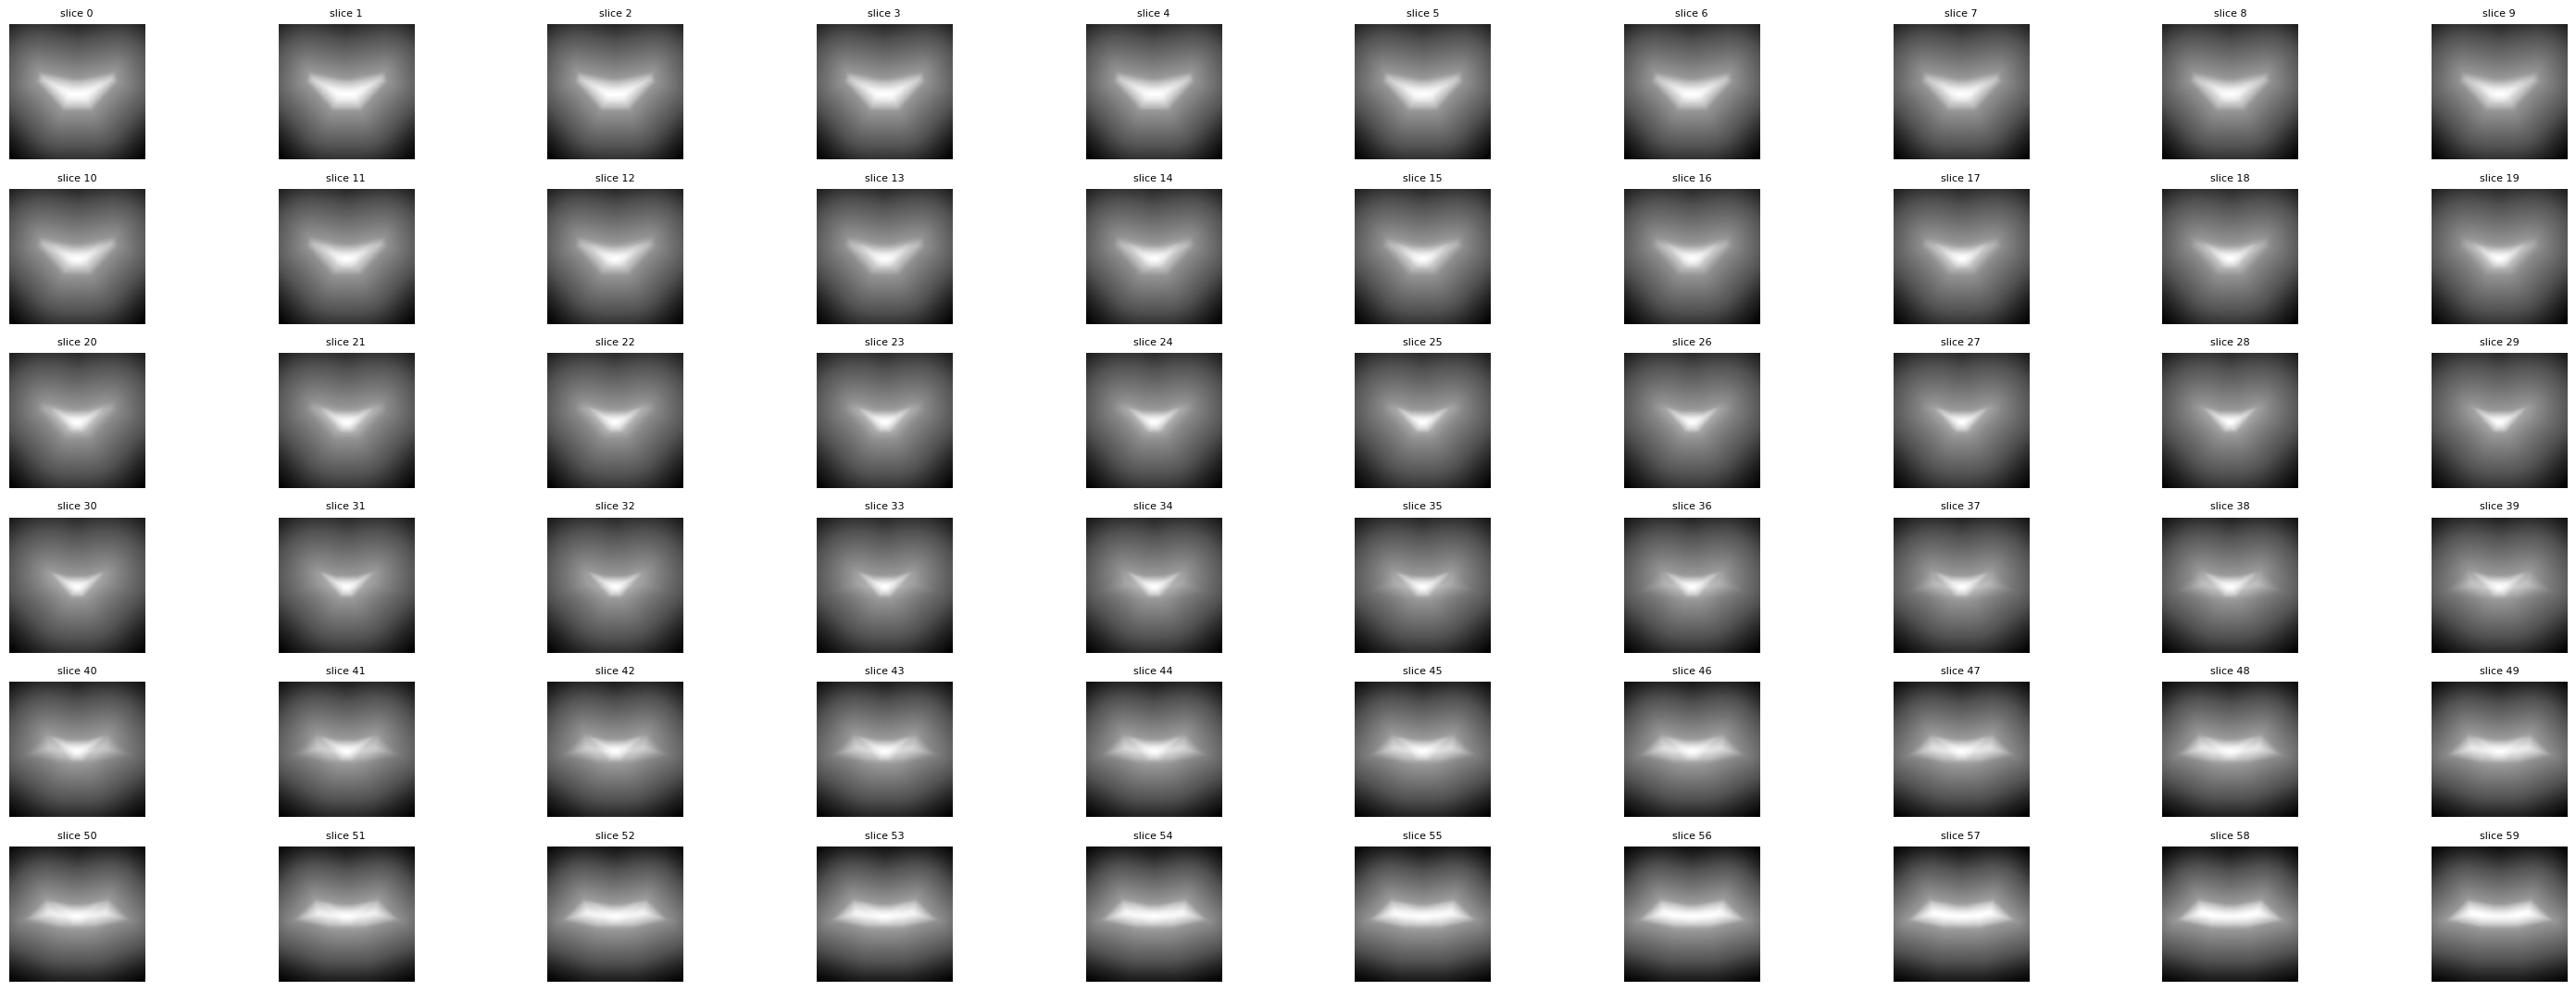

In [4]:
# Visualize the scalar fields as an image
sft.plot_scalar_overview(bracing_scalar_fields_2d, field_name="Bracing")
sft.plot_scalar_overview(profile_scalar_fields_2d, field_name="Profile")



## 3. Scalar field operation

subtract profile field with bracing field

[result] Using grid size: nx=128, ny=128
[result] Shape: (60, 16384)


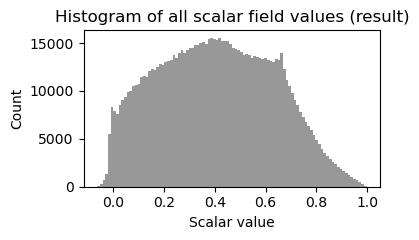

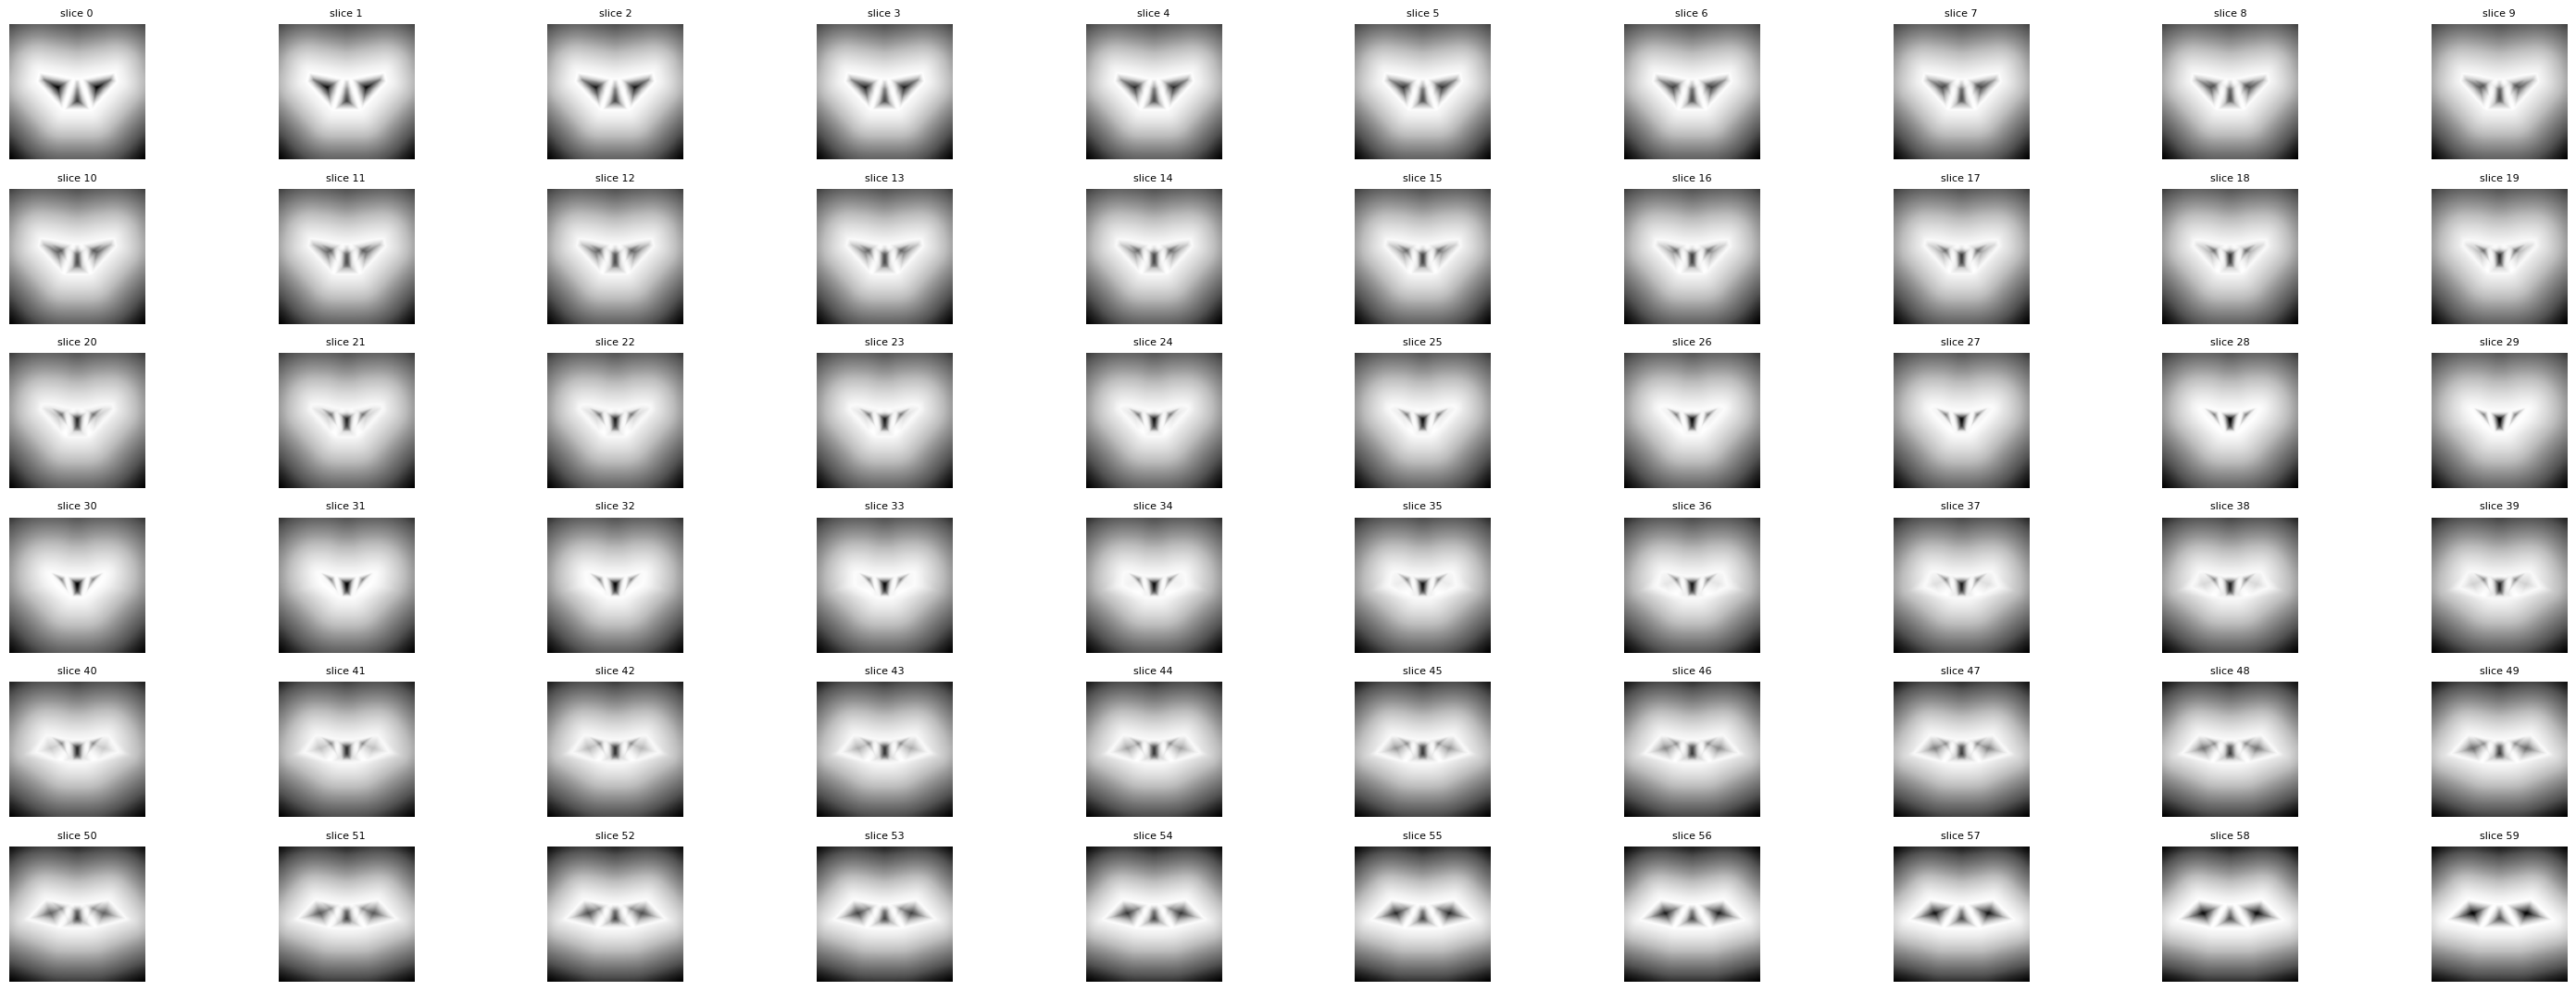

In [5]:

# tweak iso-level
iso_level_profile_new = iso_level_profile + 0.00
iso_level_bracing_new = iso_level_bracing + 0.00
    
# # normalize to make iso-curve isn on 0 for each field
# profile_scalar_fields_norm = profile_scalar_fields_2d - iso_level_profile_new
# bracing_scalar_fields_norm = bracing_scalar_fields_2d - iso_level_bracing_new

result_scalar_fields_2d = sft.compute_sf_operation(profile_scalar_fields_2d,
                         bracing_scalar_fields_2d,
                         iso_level_A= iso_level_profile_new,
                         iso_level_B=iso_level_bracing_new,
                         mode="difference")


sft.plot_scalar_overview(result_scalar_fields_2d, field_name="result")


### ISO curves preview

get iso curves from scalar fields

In [6]:
# infer_grid_from_scalar_fields 
number_of_fields, nx, ny = sft.infer_grid_from_scalar_fields(result_scalar_fields_2d)

# bounds of the grid 
bounds_min = bounds_min_profile
bounds_max = bounds_max_profile

# iso level
iso_level_result = 0.1

# world xy grid for one slice
x = np.linspace(bounds_min[0], bounds_max[0], nx)
y = np.linspace(bounds_min[1], bounds_max[1], ny)
X, Y = np.meshgrid(x, y, indexing="xy")  # X,Y both (ny, nx)


# run for all slices
iso_curves_per_slice_2d = []
for i in range(number_of_fields):
    slice_2d = result_scalar_fields_2d[i].reshape((ny, nx))
    
    curves_2d = sft.iso_curves_for_slice_2d(slice_2d, iso_level_result, X, Y)
    
    iso_curves_per_slice_2d.append(curves_2d)
    print(f"Slice {i} has {len(curves_2d)} curves.")

print(f"\n-Computed iso-curves for {number_of_fields} slices.")


Slice 0 has 4 curves.
Slice 1 has 4 curves.
Slice 2 has 4 curves.
Slice 3 has 4 curves.
Slice 4 has 4 curves.
Slice 5 has 4 curves.
Slice 6 has 4 curves.
Slice 7 has 4 curves.
Slice 8 has 4 curves.
Slice 9 has 4 curves.
Slice 10 has 4 curves.
Slice 11 has 4 curves.
Slice 12 has 4 curves.
Slice 13 has 2 curves.
Slice 14 has 2 curves.
Slice 15 has 2 curves.
Slice 16 has 4 curves.
Slice 17 has 4 curves.
Slice 18 has 4 curves.
Slice 19 has 4 curves.
Slice 20 has 4 curves.
Slice 21 has 4 curves.
Slice 22 has 4 curves.
Slice 23 has 4 curves.
Slice 24 has 4 curves.
Slice 25 has 4 curves.
Slice 26 has 4 curves.
Slice 27 has 4 curves.
Slice 28 has 4 curves.
Slice 29 has 4 curves.
Slice 30 has 4 curves.
Slice 31 has 4 curves.
Slice 32 has 4 curves.
Slice 33 has 4 curves.
Slice 34 has 4 curves.
Slice 35 has 4 curves.
Slice 36 has 6 curves.
Slice 37 has 6 curves.
Slice 38 has 6 curves.
Slice 39 has 6 curves.
Slice 40 has 6 curves.
Slice 41 has 6 curves.
Slice 42 has 6 curves.
Slice 43 has 4 curves

---------

### Create well-controlled inner bracing iso-curves (generated from profile fields)


In [ ]:
import sf_bracing as sfb 
# create 3 centroids in the profile fields, and they are equal distributed inside of profiles iso-curves (looking closed)
k_centroids = 3 

centroids_list = []
bracing_fields_list = []
prev_centroids = None

for i in range(number_of_fields):
    field = profile_scalar_fields_2d[i].reshape((ny, nx))
    # create initial bracing field by iso-level offseting from profiles iso-curves
    mask = sfb.get_profile_mask(field, iso_level=iso_level_profile)


    
    




# use centroids to create voronoi within the whole fields,

# offsetting profiles iso-curves as a space to to make interesttions with voronoi, so we can have a bracing field with 3 bracing curves

c:\Users\Daxler.Zou\AppData\Local\miniforge3\envs\meshprocess\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


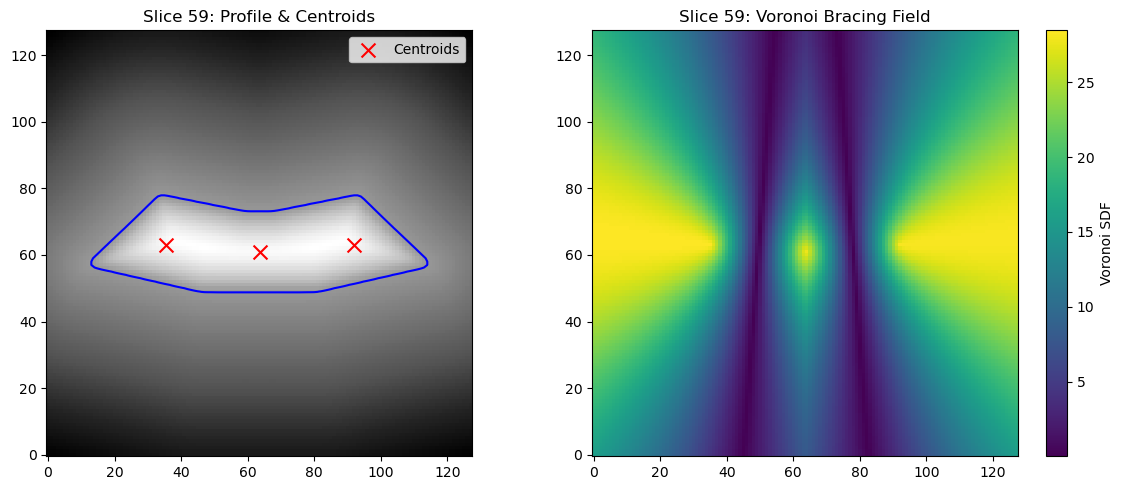

In [16]:
import sf_bracing as sfb
import importlib
importlib.reload(sfb)
import matplotlib.pyplot as plt
import numpy as np
# 1. Pick a slice index
idx = 59
# 2. Get the field for this slice
# (Assuming profile_scalar_fields_2d and sft are already loaded in the notebook)
_, nx, ny = sft.infer_grid_from_scalar_fields(profile_scalar_fields_2d)
field = profile_scalar_fields_2d[idx].reshape((ny, nx))
# 3. Generate Centroids and Bracing Field
mask = sfb.get_profile_mask(field, iso_level=iso_level_profile)
centroids = sfb.generate_centroids(mask, k=3)
voronoi_field = sfb.compute_voronoi_sdf((ny, nx), centroids)
# 4. Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Plot Profile + Centroids
ax = axes[0]
ax.imshow(field, origin='lower', cmap='Greys')
ax.contour(field, levels=[iso_level_profile], colors='blue')
ax.scatter(centroids[:, 1], centroids[:, 0], c='red', marker='x', s=100, label='Centroids')
ax.set_title(f"Slice {idx}: Profile & Centroids")
ax.legend()
# Plot Voronoi Field
ax = axes[1]
im = ax.imshow(voronoi_field, origin='lower', cmap='viridis')
plt.colorbar(im, ax=ax, label='Voronoi SDF')
ax.contour(voronoi_field, levels=[0], colors='red') # Boundary
ax.set_title(f"Slice {idx}: Voronoi Bracing Field")
plt.tight_layout()
plt.show()

In [ ]:
import sf_bracing as sfb
import sf_tools as sft
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from ipywidgets import interact, IntSlider, FloatSlider
# Reload to pick up any changes
importlib.reload(sfb)
print("Generating bracing fields for all slices...")
# 1. Setup
slice_count = profile_scalar_fields_2d.shape[0]
_, nx, ny = sft.infer_grid_from_scalar_fields(profile_scalar_fields_2d)
# 2. Generation Loop
centroids_list = []
bracing_fields_list = []
prev_centroids = None
k_centroids = 3
for i in range(slice_count):
    field = profile_scalar_fields_2d[i].reshape((ny, nx))
    mask = sfb.get_profile_mask(field, iso_level=iso_level_profile-0.01)
    
    # Centroids (with coherence)
    centroids = sfb.generate_centroids(mask, k=k_centroids, prev_centroids=prev_centroids)
    centroids_list.append(centroids)
    prev_centroids = centroids
    
    # Voronoi SDF
    voronoi_field = sfb.compute_voronoi_sdf((ny, nx), centroids)
    bracing_fields_list.append(voronoi_field)
bracing_scalar_fields_generated = np.array(bracing_fields_list)
print("Generation complete.")
# 3. Interactive Visualization & Extraction
def show_bracing_with_thickness(idx, thickness):
    profile_field = profile_scalar_fields_2d[idx].reshape((ny, nx))
    bracing_field = bracing_scalar_fields_generated[idx]
    centroids = centroids_list[idx]
    
    # Create coordinate grids for extraction
    x = np.linspace(bounds_min_profile[0], bounds_max_profile[0], nx)
    y = np.linspace(bounds_min_profile[1], bounds_max_profile[1], ny)
    X, Y = np.meshgrid(x, y)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Background
    ax.imshow(profile_field, origin='lower', cmap='Greys', alpha=0.3, 
              extent=[x.min(), x.max(), y.min(), y.max()])
    
    # 1. Profile Curve (Blue)
    ax.contour(X, Y, profile_field, levels=[iso_level_profile], colors='blue', linewidths=2)
    
    # 2. Bracing Walls (Red)
    # The Voronoi field is 0 at the center. 
    # To get walls of a certain thickness, we look at the iso-level = thickness.
    # We mask it to keep it inside the profile.
    mask = sfb.get_profile_mask(profile_field, iso_level=iso_level_profile)
    masked_bracing = np.where(mask, bracing_field, np.nan)
    
    # Plot the walls
    cs = ax.contour(X, Y, masked_bracing, levels=[thickness], colors='red', linewidths=2)
    
    # 3. Extract Curves
    # Use sf_tools to get the actual points
    curves = sft.iso_curves_for_slice_2d(masked_bracing, thickness, X, Y)
    print(f"Extracted {len(curves)} bracing loops for thickness {thickness}")
    
    # Centroids
    # Map array indices to coordinates
    cx = x[0] + centroids[:, 1] * (x[1] - x[0])
    cy = y[0] + centroids[:, 0] * (y[1] - y[0])
    ax.scatter(cx, cy, c='red', marker='x', s=80)
    
    # Legend
    custom_lines = [Line2D([0], [0], color="blue", lw=2),
                    Line2D([0], [0], color="red", lw=2)]
    ax.legend(custom_lines, ['Profile', 'Bracing Walls'])
    
    ax.set_title(f"Slice {idx}: Thickness {thickness:.3f}")
    plt.show()
interact(
    show_bracing_with_thickness,
    idx=IntSlider(min=0, max=slice_count-1, step=1, value=slice_count//2, description='Slice'),
    thickness=FloatSlider(min=0.5, max=2.0, step=0.005, value=1, description='Thickness')
)

Generating bracing fields for all slices...


c:\Users\Daxler.Zou\AppData\Local\miniforge3\envs\meshprocess\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Daxler.Zou\AppData\Local\miniforge3\envs\meshprocess\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Daxler.Zou\AppData\Local\miniforge3\envs\meshprocess\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Daxler.Zou\AppDa

Generation complete.


c:\Users\Daxler.Zou\AppData\Local\miniforge3\envs\meshprocess\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Daxler.Zou\AppData\Local\miniforge3\envs\meshprocess\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Daxler.Zou\AppData\Local\miniforge3\envs\meshprocess\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Daxler.Zou\AppDa

interactive(children=(IntSlider(value=30, description='Slice', max=59), FloatSlider(value=1.0, description='Th…

<function __main__.show_bracing_with_thickness(idx, thickness)>

------------------------------


## *Intereactive view*

In [36]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

%matplotlib inline

def show_slice(idx, iso_level_result=0.0, delta_profile=0.0, delta_bracing=0.0):
    # compute result field with current deltas
    # result_scalar_fields_2d = result_scalar_fields_2d[]

    slice_2d = result_scalar_fields_2d[idx].reshape((ny, nx))


    # print(f"Slice {idx} has {len(iso_curves_per_slice_2d[0])} curves.")

    plt.figure(figsize=(4, 4))
    plt.imshow(
        slice_2d,
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()]
    )
    plt.colorbar(label="Scalar value")
    plt.contour(X, Y, slice_2d, levels=[iso_level_result], colors="white", linewidths=1.0)
    plt.title(f"Slice {idx} with iso-level\n{round(iso_level_result, 6)}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()


number_of_fields = result_scalar_fields_2d.shape[0]

interact(
    show_slice,
    idx=IntSlider(min=0, max=number_of_fields - 1, step=1, value=20, description="slice_idx"),
    iso_level_result=FloatSlider(min=-0.1, max=0.1, step=0.001, value=0.0, description="iso_level", readout_format=".3f"),
    delta_profile=FloatSlider(min=-0.05, max=0.05, step=0.0005, value=0.0, description="delta_profile", readout_format=".4f"),
    delta_bracing=FloatSlider(min=-0.05, max=0.05, step=0.0005, value=0.0, description="delta_bracing", readout_format=".4f"),
)


interactive(children=(IntSlider(value=20, description='slice_idx', max=59), FloatSlider(value=0.0, description…

<function __main__.show_slice(idx, iso_level_result=0.0, delta_profile=0.0, delta_bracing=0.0)>

**try to fix small gap in the bracing part  (WIP)**

In [12]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
from scipy.ndimage import binary_closing

%matplotlib inline

def show_slice(idx, iso_level_result=0.0, delta_profile=0.0, delta_bracing=0.0, morph_iter=1):
    # compute result field with current deltas
    

    slice_2d = result_scalar_fields_2d[idx].reshape((ny, nx))
   
    #  morphological closing on a binary mask
    #  inside area:  result<=iso_level_result
    inside = slice_2d <= iso_level_result

    # close small galps
    closed_mask = binary_closing(inside,iterations=morph_iter)

    print(f"Result shape: {result_scalar_fields_2d.shape}")
    print(f"Result min: {result_scalar_fields_2d.min()}")
    print(f"Result max: {result_scalar_fields_2d.max()}")
    print(f"Result mean: {result_scalar_fields_2d.mean()}")



    print(f"Slice 0 has {len(slice_2d[0])} curves.")

    plt.figure(figsize=(4, 4))
    plt.imshow(
        slice_2d,
        origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()]
    )
    plt.colorbar(label="Scalar value")
    plt.contour(X, Y, closed_mask.astype(float), levels=[iso_level_result], colors="white", linewidths=1.0)
    plt.title(f"Slice {idx} with iso-level\n{round(iso_level_result, 6)}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()



number_of_fields = result_scalar_fields_2d.shape[0]

interact(
    show_slice,
    idx=IntSlider(min=0, max=number_of_fields - 1, step=1, value=20, description="slice_idx"),
    iso_level_result=FloatSlider(min=-0.1, max=0.1, step=0.001, value=0.0, description="iso_level", readout_format=".3f"),
    delta_profile=FloatSlider(min=-0.05, max=0.5, step=0.0005, value=0.0, description="delta_profile", readout_format=".4f"),
    delta_bracing=FloatSlider(min=-0.05, max=0.05, step=0.0005, value=0.0, description="delta_bracing", readout_format=".4f"),
    morph_iter=IntSlider(min=0, max=10, step=1, value=1, description="morph_iter")
)


interactive(children=(IntSlider(value=20, description='slice_idx', max=59), FloatSlider(value=0.0, description…

<function __main__.show_slice(idx, iso_level_result=0.0, delta_profile=0.0, delta_bracing=0.0, morph_iter=1)>

### Scalar field operation